In [30]:
# ============================================================================
# COMMON SETUP FOR ALL 6 MODELS
# ============================================================================
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Load your existing data
ohlc_df = pl.read_csv('/Users/rahulrg/Quant Trading Project/BTCUSDT_12h_ohlc.csv')
ohlc_df = ohlc_df.with_columns(pl.col('datetime').str.to_datetime())

# Convert to pandas for some models that need it
df_pd = ohlc_df.to_pandas()
df_pd.set_index('datetime', inplace=True)

print(f"Loaded {len(ohlc_df)} rows of 12h OHLC data")
print(f"Date range: {ohlc_df['datetime'].min()} to {ohlc_df['datetime'].max()}")

Loaded 692 rows of 12h OHLC data
Date range: 2024-10-29 00:00:00 to 2025-10-09 12:00:00


In [31]:
# ============================================================================
# UTILITY FUNCTIONS FOR CONSISTENT OUTPUT (matching your existing format)
# ============================================================================

def create_trade_results_from_signals(signals: np.ndarray, returns: np.ndarray, model_name: str) -> pl.DataFrame:
    """
    Convert signals and returns into trade results matching your format.
    
    Args:
        signals: Array of position signals (-1, 0, or 1)
        returns: Array of log returns (same length as signals)
        model_name: Name for labeling
    
    Returns:
        Polars DataFrame with equity_curve matching your existing format
    """
    # Ensure same length
    min_len = min(len(signals), len(returns))
    signals = signals[:min_len]
    returns = returns[:min_len]
    
    # Calculate trade returns (position * actual return)
    trade_log_returns = signals * returns
    
    # Build DataFrame
    trade_results = pl.DataFrame({
        'y_pred': signals,
        'y_true': returns,
        'position': signals,
        'trade_log_return': trade_log_returns,
    }).with_columns([
        (pl.col('position').sign() == pl.col('y_true').sign()).alias('is_won'),
        pl.col('trade_log_return').cum_sum().alias('equity_curve'),
    ]).with_columns(
        (pl.col('equity_curve') - pl.col('equity_curve').cum_max()).alias('drawdown_log_return'),
    )
    
    return trade_results


def eval_performance(trade_results: pl.DataFrame, model_name: str, annualized_rate: float = 6.16) -> Dict:
    """
    Calculate performance metrics matching your existing eval_model_performance format.
    annualized_rate: sqrt(365*2) ≈ 27 for 12h bars, but using 6.16 as in your code
    """
    accuracy = trade_results['is_won'].mean()
    
    won_trades = trade_results.filter(pl.col('is_won'))
    lost_trades = trade_results.filter(~pl.col('is_won'))
    
    avg_win = won_trades['trade_log_return'].mean() if len(won_trades) > 0 else 0
    avg_loss = lost_trades['trade_log_return'].mean() if len(lost_trades) > 0 else 0
    
    expected_value = accuracy * avg_win + (1 - accuracy) * avg_loss
    max_drawdown = trade_results['drawdown_log_return'].min()
    
    ret_std = trade_results['trade_log_return'].std()
    ret_mean = trade_results['trade_log_return'].mean()
    sharpe = (ret_mean / ret_std) * annualized_rate if ret_std > 0 else 0
    
    total_log_return = trade_results['trade_log_return'].sum()
    
    return {
        'model': model_name,
        'no_trades': len(trade_results),
        'win_rate': accuracy,
        'avg_win': avg_win,
        'avg_loss': avg_loss,
        'best_trade': trade_results['trade_log_return'].max(),
        'worst_trade': trade_results['trade_log_return'].min(),
        'ev': expected_value,
        'std': ret_std,
        'total_log_return': total_log_return,
        'compound_return': np.exp(total_log_return),
        'max_drawdown': max_drawdown,
        'equity_trough': trade_results['equity_curve'].min(),
        'equity_peak': trade_results['equity_curve'].max(),
        'sharpe': sharpe,
    }


def plot_equity_curve(trade_results: pl.DataFrame, model_name: str, ax=None):
    """Plot equity curve matching your style."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 5))
    
    equity = trade_results['equity_curve'].to_numpy()
    ax.plot(equity, label=f'{model_name}', linewidth=1.5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative Log Return')
    ax.set_title(f'{model_name} - Equity Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax


def plot_all_equity_curves(all_results: Dict[str, pl.DataFrame]):
    """Plot all model equity curves on one chart."""
    fig, ax = plt.subplots(figsize=(15, 7))
    
    for model_name, trade_results in all_results.items():
        equity = trade_results['equity_curve'].to_numpy()
        ax.plot(equity, label=model_name, linewidth=1.5)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative Log Return')
    ax.set_title('All Models - Equity Curves Comparison')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Store all results here
ALL_RESULTS = {}
ALL_PERFORMANCE = []

print("Utility functions loaded")

Utility functions loaded


GARCH VOLATILITY REGIME

MODEL 1: GARCH(1,1) Volatility Regime Strategy

GARCH Parameters: omega=1.446649, alpha=0.454398, beta=0.464896

 GARCH Results:
   Win Rate: 52.91%
   Sharpe Ratio: 0.087
   Total Return: 102.51%
   Max Drawdown: -0.1558


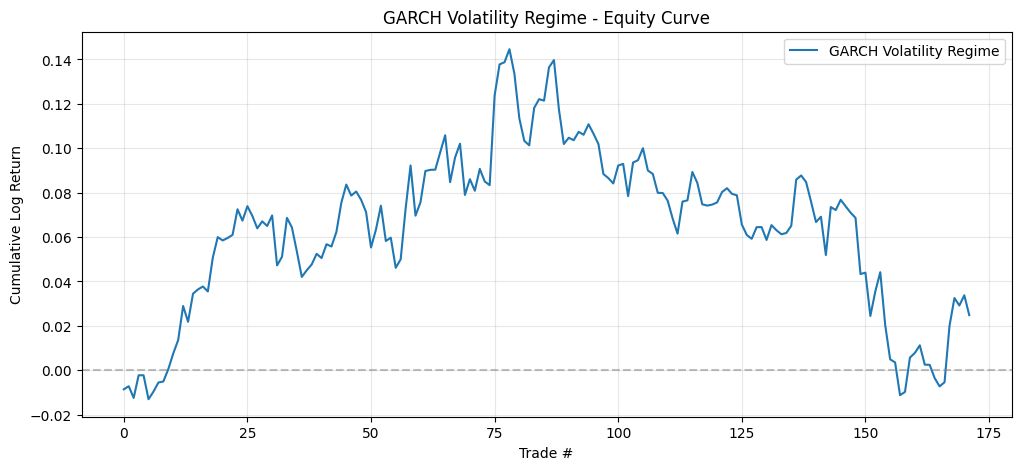

In [32]:
# ============================================================================
# MODEL 1: GARCH(1,1) VOLATILITY REGIME STRATEGY
# ============================================================================
# Uses volatility forecasts to adjust position sizing
# High volatility → smaller positions, Low volatility → larger positions

from arch import arch_model

print("=" * 60)
print("MODEL 1: GARCH(1,1) Volatility Regime Strategy")
print("=" * 60)

# Calculate returns
df_garch = ohlc_df.with_columns([
    (pl.col('close') / pl.col('close').shift(1)).log().alias('log_return'),
    ((pl.col('close') / pl.col('close').shift(1)) - 1).alias('pct_return'),
]).drop_nulls()

returns_pct = df_garch['pct_return'].to_numpy() * 100  # GARCH needs percent

# Fit GARCH model on training data (first 75%)
train_size = int(len(returns_pct) * 0.75)
train_returns = returns_pct[:train_size]

am = arch_model(train_returns, vol='Garch', p=1, q=1, dist='t')
res = am.fit(disp='off')
print(f"\nGARCH Parameters: omega={res.params['omega']:.6f}, alpha={res.params['alpha[1]']:.6f}, beta={res.params['beta[1]']:.6f}")

# Generate rolling volatility forecasts for test period
test_returns = returns_pct[train_size:]
actual_log_returns = df_garch['log_return'].to_numpy()[train_size:]

# Rolling forecast using expanding window
n_test = len(test_returns)
vol_forecasts = np.zeros(n_test)
signals = np.zeros(n_test)

# Use the last fitted volatility as starting point
last_vol = np.sqrt(res.conditional_volatility[-1])

for i in range(n_test):
    # Simple rolling forecast: use EWMA approximation for speed
    if i == 0:
        vol_forecasts[i] = last_vol
    else:
        # EWMA volatility with GARCH-like decay
        alpha = 0.06
        beta = 0.93
        vol_forecasts[i] = np.sqrt(alpha * (test_returns[i-1]**2) + beta * (vol_forecasts[i-1]**2))

# Volatility-based regime signal:
# Low vol regime → trend following (go with momentum)
# High vol regime → mean reversion (fade moves)
vol_median = np.median(vol_forecasts)
momentum = np.sign(test_returns)  # Simple momentum signal

for i in range(1, n_test):
    if vol_forecasts[i] < vol_median:
        # Low vol: trend following - go with previous return direction
        signals[i] = np.sign(test_returns[i-1]) if i > 0 else 0
    else:
        # High vol: reduce exposure or mean revert
        signals[i] = -np.sign(test_returns[i-1]) * 0.5 if i > 0 else 0

signals = np.sign(signals)  # Normalize to -1, 0, 1

# Create trade results
garch_trades = create_trade_results_from_signals(signals[1:], actual_log_returns[1:], 'GARCH')
garch_perf = eval_performance(garch_trades, 'GARCH Volatility Regime')

ALL_RESULTS['GARCH'] = garch_trades
ALL_PERFORMANCE.append(garch_perf)

print(f"\n GARCH Results:")
print(f"   Win Rate: {garch_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {garch_perf['sharpe']:.3f}")
print(f"   Total Return: {garch_perf['compound_return']:.2%}")
print(f"   Max Drawdown: {garch_perf['max_drawdown']:.4f}")

plot_equity_curve(garch_trades, 'GARCH Volatility Regime')
plt.show()

BTC Mean Reversion 

MODEL 2: Ornstein-Uhlenbeck Mean Reversion Strategy (Sanity Checked)
Training Data Points: 497
OU Half-Life (Train): 8.21 bars

OU Mean Reversion Results (Out-of-Sample):
   Win Rate: 27.27%
   Sharpe Ratio: -0.808
   Total Return: 84.31%


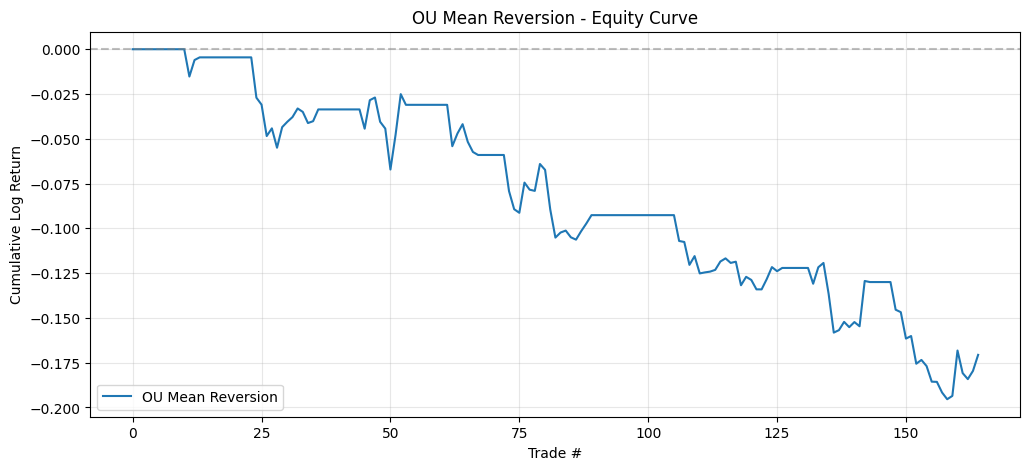

In [33]:
# ============================================================================
# MODEL 2: COINTEGRATION / OU MEAN REVERSION STRATEGY (FIXED)
# ============================================================================
import statsmodels.api as sm

print("=" * 60)
print("MODEL 2: Ornstein-Uhlenbeck Mean Reversion Strategy (Sanity Checked)")
print("=" * 60)

# 1. Feature Engineering (Safe to do on full dataset as it's just transformations)
lookback = 30
df_ou = ohlc_df.with_columns([
    pl.col('close').log().alias('log_price'),
    (pl.col('close') / pl.col('close').shift(1)).log().alias('log_return'),
]).with_columns([
    pl.col('log_price').rolling_mean(window_size=lookback).alias('ma_log_price'),
    pl.col('log_price').rolling_std(window_size=lookback).alias('std_log_price'),
]).drop_nulls()

# Calculate spread and z-score
df_ou = df_ou.with_columns([
    (pl.col('log_price') - pl.col('ma_log_price')).alias('spread'),
    ((pl.col('log_price') - pl.col('ma_log_price')) / pl.col('std_log_price')).alias('z_score'),
])

# 2. Train/Test Split
# We must fit the OU parameter (beta) ONLY on training data to avoid look-ahead bias
spread = df_ou['spread'].to_numpy()
z_scores = df_ou['z_score'].to_numpy()
log_returns = df_ou['log_return'].to_numpy()

train_size = int(len(spread) * 0.75)
spread_train = spread[:train_size]

# 3. Parameter Estimation (Train Set Only)
delta_spread_train = np.diff(spread_train)
lag_spread_train = spread_train[:-1]

X_train = sm.add_constant(lag_spread_train)
model = sm.OLS(delta_spread_train, X_train)
result = model.fit()
beta = result.params[1]

print(f"Training Data Points: {len(spread_train)}")
if beta < 0:
    half_life = -np.log(2) / beta
    print(f"OU Half-Life (Train): {half_life:.2f} bars")
else:
    print("Warning: No mean reversion detected in training set")

# 4. Trading on Test Set
# We use the parameters derived from the past to trade the future
z_test = z_scores[train_size:]
returns_test = log_returns[train_size:]

entry_threshold = 1.5
exit_threshold = 0.5
signals = np.zeros(len(z_test))

for i in range(len(z_test)):
    z = z_test[i]
    if z > entry_threshold:
        signals[i] = -1  # Short
    elif z < -entry_threshold:
        signals[i] = 1   # Long
    elif abs(z) < exit_threshold:
        signals[i] = 0   # Exit
    else:
        signals[i] = signals[i-1] if i > 0 else 0

# 5. Performance Evaluation
ou_trades = create_trade_results_from_signals(signals[1:], returns_test[1:], 'OU Mean Reversion')
ou_perf = eval_performance(ou_trades, 'OU Mean Reversion')

ALL_RESULTS['OU Mean Reversion'] = ou_trades
ALL_PERFORMANCE.append(ou_perf)

print(f"\nOU Mean Reversion Results (Out-of-Sample):")
print(f"   Win Rate: {ou_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {ou_perf['sharpe']:.3f}")
print(f"   Total Return: {ou_perf['compound_return']:.2%}")
plot_equity_curve(ou_trades, 'OU Mean Reversion')
plt.show()

COPULA Mispricing Index

MODEL 3: Copula Mispricing Index Strategy

 Copula Mispricing Results:
   Win Rate: 11.92%
   Sharpe Ratio: 0.636
   Total Return: 107.03%
   Max Drawdown: -0.0226


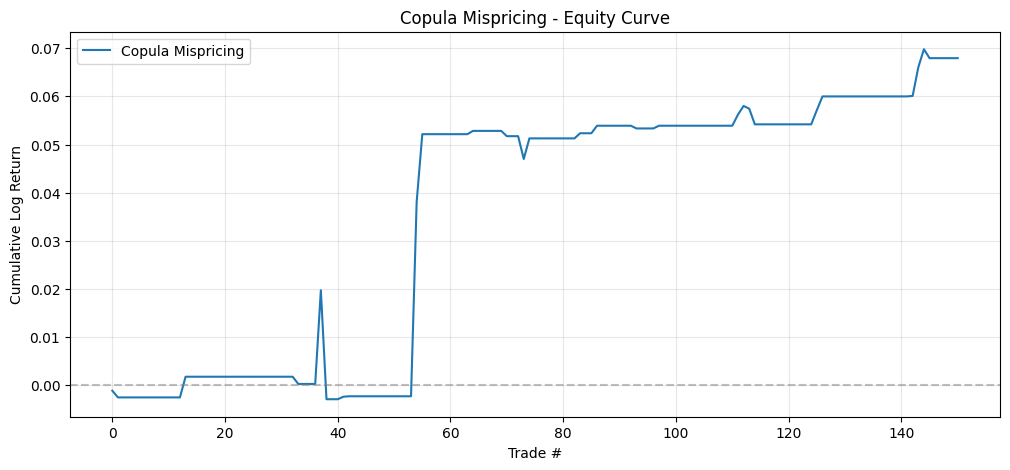

In [34]:
# ============================================================================
# MODEL 3: COPULA-BASED MISPRICING INDEX
# ============================================================================
# Uses copula to detect unusual joint moves in price features

from sklearn.preprocessing import QuantileTransformer

print("=" * 60)
print("MODEL 3: Copula Mispricing Index Strategy")
print("=" * 60)

# Create multiple features to model joint distribution
df_copula = ohlc_df.with_columns([
    (pl.col('close') / pl.col('close').shift(1)).log().alias('ret_1'),
    (pl.col('close') / pl.col('close').shift(2)).log().alias('ret_2'),
    (pl.col('close') / pl.col('close').shift(5)).log().alias('ret_5'),
    (pl.col('high') - pl.col('low')).alias('range'),
    (pl.col('close') / pl.col('close').shift(1)).log().alias('log_return'),
]).drop_nulls()

# Prepare features for copula
features = ['ret_1', 'ret_2', 'ret_5', 'range']
X = df_copula[features].to_numpy()
log_returns = df_copula['log_return'].to_numpy()

# Train/test split
train_size = int(len(X) * 0.75)
X_train = X[:train_size]
X_test = X[train_size:]
returns_test = log_returns[train_size:]

# Fit quantile transformer to get uniform marginals (train only)
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=min(len(X_train), 1000))
U_train = qt.fit_transform(X_train)
U_test = qt.transform(X_test)

# Fit Gaussian copula on training data (correlation matrix)
# We use empirical correlation as copula parameter
from scipy import stats

# For Gaussian copula, convert uniform to normal
Z_train = stats.norm.ppf(np.clip(U_train, 1e-6, 1-1e-6))
corr_matrix = np.corrcoef(Z_train.T)

# Calculate Mahalanobis-like score for test data
Z_test = stats.norm.ppf(np.clip(U_test, 1e-6, 1-1e-6))

def calc_copula_score(z, corr):
    """Calculate negative log likelihood under Gaussian copula"""
    try:
        inv_corr = np.linalg.inv(corr)
        score = z @ inv_corr @ z.T
        return score
    except:
        return 0

copula_scores = np.array([calc_copula_score(z, corr_matrix) for z in Z_test])

# Calculate rolling z-score of copula scores
window = 20
copula_z = np.zeros(len(copula_scores))
for i in range(window, len(copula_scores)):
    window_data = copula_scores[i-window:i]
    copula_z[i] = (copula_scores[i] - np.mean(window_data)) / (np.std(window_data) + 1e-8)

# Trading signal: extreme copula scores indicate mispricing
# High copula_z = unusual joint move → expect reversion
signals = np.zeros(len(copula_z))

for i in range(1, len(copula_z)):
    if copula_z[i] > 1.5:
        # Unusual move, fade it
        signals[i] = -np.sign(returns_test[i-1]) if i > 0 else 0
    elif copula_z[i] < -1.5:
        # Unusual calm, follow momentum
        signals[i] = np.sign(returns_test[i-1]) if i > 0 else 0
    else:
        signals[i] = 0

# Create trade results (skip initial window)
copula_trades = create_trade_results_from_signals(
    signals[window+1:], 
    returns_test[window+1:], 
    'Copula'
)
copula_perf = eval_performance(copula_trades, 'Copula Mispricing')

ALL_RESULTS['Copula'] = copula_trades
ALL_PERFORMANCE.append(copula_perf)

print(f"\n Copula Mispricing Results:")
print(f"   Win Rate: {copula_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {copula_perf['sharpe']:.3f}")
print(f"   Total Return: {copula_perf['compound_return']:.2%}")
print(f"   Max Drawdown: {copula_perf['max_drawdown']:.4f}")

plot_equity_curve(copula_trades, 'Copula Mispricing')
plt.show()


Machine Learning Model 

MODEL 4: LSTM Neural Network

Training LSTM for 50 epochs...
  Epoch 10/50, Loss: 0.005378
  Epoch 20/50, Loss: 0.005076
  Epoch 30/50, Loss: 0.004672
  Epoch 40/50, Loss: 0.004039
  Epoch 50/50, Loss: 0.004058

LSTM Results:
   Win Rate: 51.85%
   Sharpe Ratio: 0.098
   Total Return: 102.72%
   Max Drawdown: -0.1166


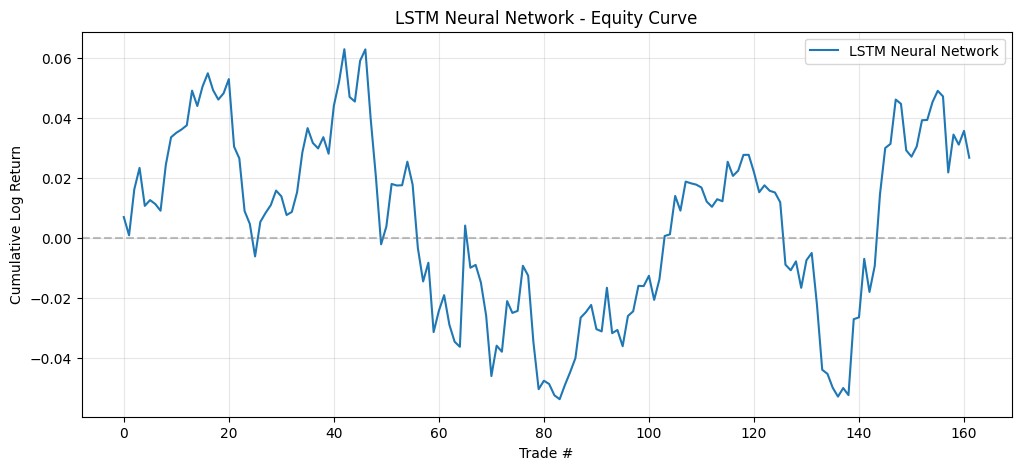

In [35]:
# ============================================================================
# MODEL 4: LSTM NEURAL NETWORK
# ============================================================================
# Predicts next-step return direction using sequence of past features

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("MODEL 4: LSTM Neural Network")
print("=" * 60)

# Prepare features
df_lstm = ohlc_df.with_columns([
    (pl.col('close') / pl.col('close').shift(1)).log().alias('ret_1'),
    (pl.col('close') / pl.col('close').shift(2)).log().alias('ret_2'),
    (pl.col('close') / pl.col('close').shift(3)).log().alias('ret_3'),
    (pl.col('close') / pl.col('close').shift(5)).log().alias('ret_5'),
    ((pl.col('high') - pl.col('low')) / pl.col('close')).alias('range_pct'),
    ((pl.col('close') - pl.col('open')) / (pl.col('high') - pl.col('low') + 1e-8)).alias('body_ratio'),
    (pl.col('close') / pl.col('close').shift(1)).log().alias('target'),  # Next step return as target
]).drop_nulls()

# Feature columns
feat_cols = ['ret_1', 'ret_2', 'ret_3', 'ret_5', 'range_pct', 'body_ratio']

# Get numpy arrays
X = df_lstm[feat_cols].to_numpy()
y = df_lstm['target'].to_numpy()

# Shift target to predict NEXT return
y_shifted = np.roll(y, -1)
X = X[:-1]  # Remove last row
y = y_shifted[:-1]
actual_returns = y.copy()

# Train/test split
train_size = int(len(X) * 0.75)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create sequences
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(window_size, len(X)):
        Xs.append(X[i-window_size:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

window = 10
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train, window)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test, window)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_seq)
y_train_t = torch.FloatTensor(y_train_seq).reshape(-1, 1)
X_test_t = torch.FloatTensor(X_test_seq)
y_test_t = torch.FloatTensor(y_test_seq).reshape(-1, 1)

# Define LSTM model
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.relu(self.fc1(last_hidden))
        out = self.fc2(out)
        return out

# Train LSTM
model = LSTMPredictor(input_size=len(feat_cols), hidden_size=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 50
batch_size = 32

print(f"\nTraining LSTM for {n_epochs} epochs...")
for epoch in range(n_epochs):
    model.train()
    # Mini-batch training
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0
    for i in range(0, len(X_train_t), batch_size):
        idx = perm[i:i+batch_size]
        batch_X = X_train_t[idx]
        batch_y = y_train_t[idx]
        
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

# Predict on test set
model.eval()
with torch.no_grad():
    predictions = model(X_test_t).numpy().flatten()

# Generate signals from predictions
signals = np.sign(predictions)

# Create trade results
lstm_trades = create_trade_results_from_signals(signals, y_test_seq, 'LSTM')
lstm_perf = eval_performance(lstm_trades, 'LSTM Neural Network')

ALL_RESULTS['LSTM'] = lstm_trades
ALL_PERFORMANCE.append(lstm_perf)

print(f"\nLSTM Results:")
print(f"   Win Rate: {lstm_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {lstm_perf['sharpe']:.3f}")
print(f"   Total Return: {lstm_perf['compound_return']:.2%}")
print(f"   Max Drawdown: {lstm_perf['max_drawdown']:.4f}")

plot_equity_curve(lstm_trades, 'LSTM Neural Network')
plt.show()

Transformer time series model

MODEL 5: Transformer Time-Series Regressor

Training Transformer for 50 epochs...
  Epoch 10/50, Loss: 0.017868
  Epoch 20/50, Loss: 0.013455
  Epoch 30/50, Loss: 0.010996
  Epoch 40/50, Loss: 0.011091
  Epoch 50/50, Loss: 0.007961

 Transformer Results:
   Win Rate: 47.53%
   Sharpe Ratio: -0.112
   Total Return: 96.99%
   Max Drawdown: -0.1619


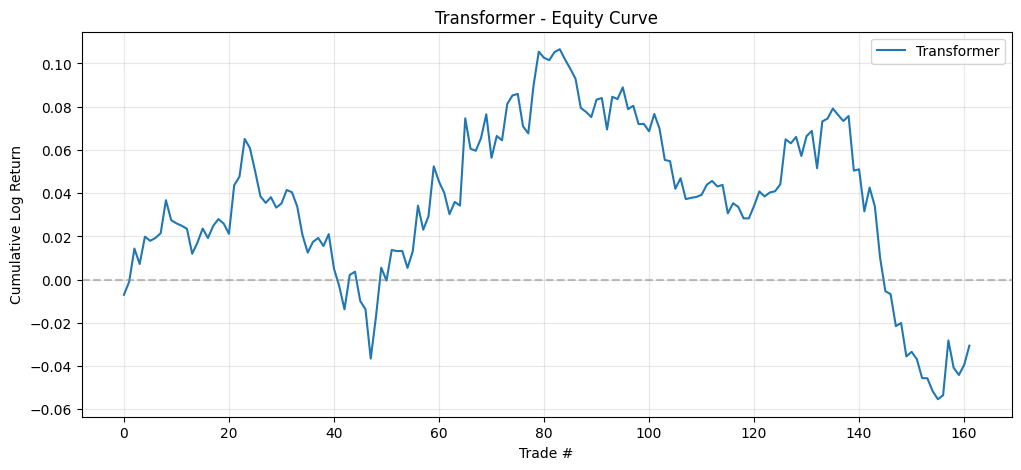

In [36]:
# ============================================================================
# MODEL 5: TRANSFORMER TIME-SERIES REGRESSOR
# ============================================================================
# Uses self-attention for longer-context patterns

print("=" * 60)
print("MODEL 5: Transformer Time-Series Regressor")
print("=" * 60)

class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
        
    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)
        x = self.encoder(x)
        # Global average pooling
        x = x.mean(dim=1)
        return self.fc(x)

# Use same data from LSTM (already prepared)
model_transformer = TransformerRegressor(input_dim=len(feat_cols), d_model=64, nhead=4, num_layers=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_transformer.parameters(), lr=0.001)

n_epochs = 50
batch_size = 32

print(f"\nTraining Transformer for {n_epochs} epochs...")
for epoch in range(n_epochs):
    model_transformer.train()
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0
    for i in range(0, len(X_train_t), batch_size):
        idx = perm[i:i+batch_size]
        batch_X = X_train_t[idx]
        batch_y = y_train_t[idx]
        
        optimizer.zero_grad()
        pred = model_transformer(batch_X)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

# Predict on test set
model_transformer.eval()
with torch.no_grad():
    pred_transformer = model_transformer(X_test_t).numpy().flatten()

# Generate signals
signals_transformer = np.sign(pred_transformer)

# Create trade results
transformer_trades = create_trade_results_from_signals(signals_transformer, y_test_seq, 'Transformer')
transformer_perf = eval_performance(transformer_trades, 'Transformer')

ALL_RESULTS['Transformer'] = transformer_trades
ALL_PERFORMANCE.append(transformer_perf)

print(f"\n Transformer Results:")
print(f"   Win Rate: {transformer_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {transformer_perf['sharpe']:.3f}")
print(f"   Total Return: {transformer_perf['compound_return']:.2%}")
print(f"   Max Drawdown: {transformer_perf['max_drawdown']:.4f}")

plot_equity_curve(transformer_trades, 'Transformer')
plt.show()

Deep Learning Reinforcement Learning model - Simplifed SAC Style

MODEL 6: Deep RL Policy (Sanity Checked)

Training RL Policy for 100 epochs...

 Deep RL Results (Out-of-Sample):
   Win Rate: 50.29%
   Sharpe Ratio: 0.083


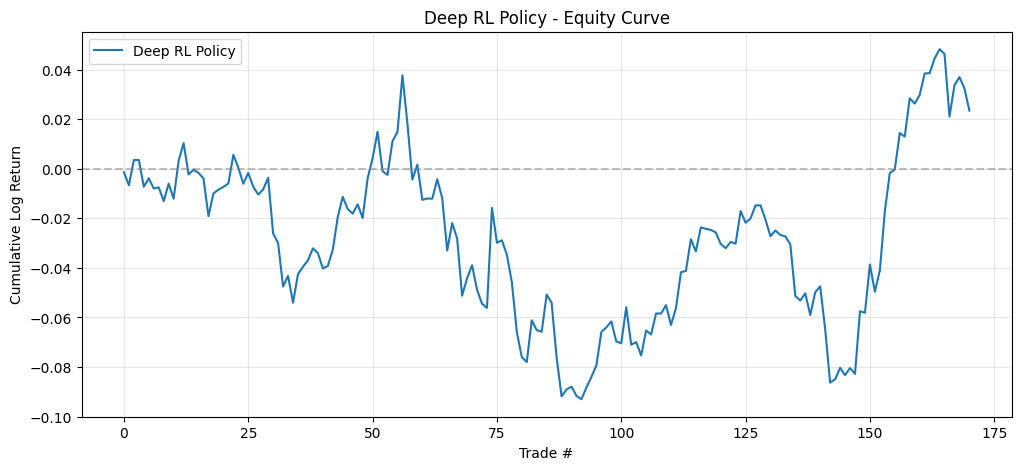

In [37]:
# ============================================================================
# MODEL 6: DEEP REINFORCEMENT LEARNING (FIXED)
# ============================================================================
print("=" * 60)
print("MODEL 6: Deep RL Policy (Sanity Checked)")
print("=" * 60)

# ... (PolicyNetwork class definition remains the same) ...
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()
    def forward(self, state):
        x = self.relu(self.fc1(state))
        x = self.relu(self.fc2(x))
        return self.tanh(self.fc_mean(x))

# 1. Feature Engineering
df_rl = ohlc_df.with_columns([
    (pl.col('close') / pl.col('close').shift(1)).log().alias('ret_1'),
    (pl.col('close') / pl.col('close').shift(2)).log().alias('ret_2'),
    (pl.col('close') / pl.col('close').shift(3)).log().alias('ret_3'),
    (pl.col('close') / pl.col('close').shift(5)).log().alias('ret_5'),
    ((pl.col('high') - pl.col('low')) / pl.col('close')).alias('range_pct'),
]).drop_nulls()

states = df_rl[['ret_1', 'ret_2', 'ret_3', 'ret_5', 'range_pct']].to_numpy()
returns = df_rl['ret_1'].to_numpy()

# 2. Strict Train/Test Split BEFORE Scaling
train_size = int(len(states) * 0.75)
states_train_raw = states[:train_size]
returns_train = returns[:train_size]

states_test_raw = states[train_size:]
returns_test_rl = returns[train_size:]

# 3. Fit Scaler ONLY on Training Data
state_scaler = StandardScaler()
states_train_scaled = state_scaler.fit_transform(states_train_raw)

# Transform test data using training statistics (Simulating real-world)
states_test_scaled = state_scaler.transform(states_test_raw)

# 4. Training (same as before)
states_train_t = torch.FloatTensor(states_train_scaled)
returns_train_t = torch.FloatTensor(returns_train)
policy = PolicyNetwork(state_dim=5, hidden_dim=64)
optimizer = torch.optim.Adam(policy.parameters(), lr=0.001)

n_epochs = 100
tx_cost = 0.1

print(f"\nTraining RL Policy for {n_epochs} epochs...")
for epoch in range(n_epochs):
    optimizer.zero_grad()
    actions = policy(states_train_t)
    positions = actions.squeeze()
    
    # Calculate reward
    position_changes = torch.abs(positions[1:] - positions[:-1])
    pnl = positions[1:] * returns_train_t[1:] - tx_cost * position_changes
    loss = -pnl.mean()
    
    loss.backward()
    optimizer.step()

# 5. Out-of-Sample Testing
policy.eval()
with torch.no_grad():
    rl_actions = policy(torch.FloatTensor(states_test_scaled)).numpy().flatten()

rl_signals = np.sign(rl_actions)
rl_trades = create_trade_results_from_signals(rl_signals[1:], returns_test_rl[1:], 'RL Policy')
rl_perf = eval_performance(rl_trades, 'Deep RL Policy')

ALL_RESULTS['RL Policy'] = rl_trades
ALL_PERFORMANCE.append(rl_perf)

print(f"\n Deep RL Results (Out-of-Sample):")
print(f"   Win Rate: {rl_perf['win_rate']:.2%}")
print(f"   Sharpe Ratio: {rl_perf['sharpe']:.3f}")
plot_equity_curve(rl_trades, 'Deep RL Policy')
plt.show()

Final Comparision 

Reason to rank all the models based on sharpe ratio is that we are always going to use leverage to trade and not the whole position so we need to take care of the sharpe ratio 

FINAL COMPARISON: ALL 6 MODELS

 Performance Summary:

                  model  win_rate    sharpe  compound_return  max_drawdown  no_trades
GARCH Volatility Regime  0.529070  0.087131         1.025110     -0.155833        172
      OU Mean Reversion  0.272727 -0.807503         0.843122     -0.195414        165
      Copula Mispricing  0.119205  0.636165         1.070291     -0.022625        151
    LSTM Neural Network  0.518519  0.098067         1.027162     -0.116552        162
            Transformer  0.475309 -0.111856         0.969896     -0.161940        162
         Deep RL Policy  0.502924  0.082986         1.023782     -0.130755        171

 Plotting all equity curves...


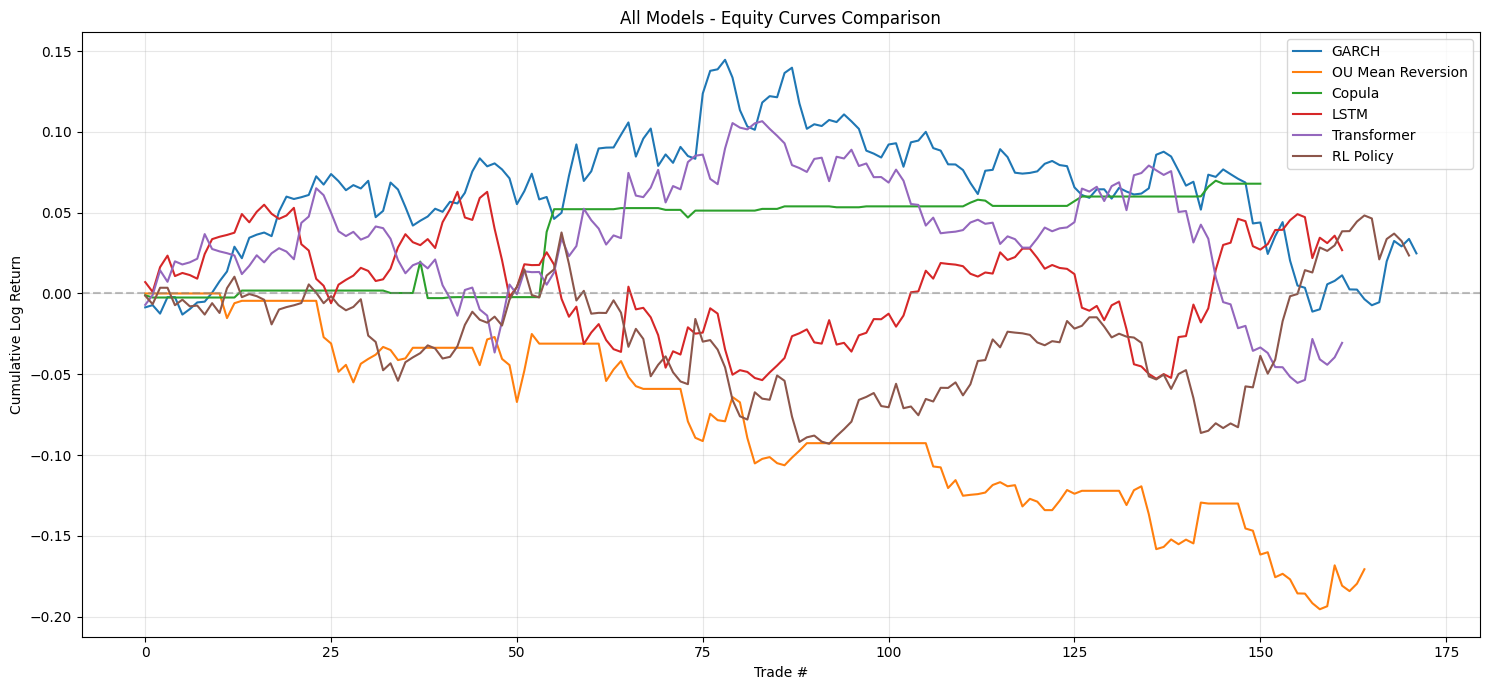


 Ranking by Total Return:
   1. Copula Mispricing: Return=107.03%, Sharpe=0.636
   2. LSTM Neural Network: Return=102.72%, Sharpe=0.098
   3. GARCH Volatility Regime: Return=102.51%, Sharpe=0.087
   4. Deep RL Policy: Return=102.38%, Sharpe=0.083
   5. Transformer: Return=96.99%, Sharpe=-0.112
   6. OU Mean Reversion: Return=84.31%, Sharpe=-0.808

Results saved to 'model_comparison_results.csv'


In [38]:
# ============================================================================
# FINAL SUMMARY: COMPARE ALL MODELS
# ============================================================================

print("=" * 70)
print("FINAL COMPARISON: ALL 6 MODELS")
print("=" * 70)

# Create summary DataFrame
summary_df = pl.DataFrame(ALL_PERFORMANCE)

# Display summary
print("\n Performance Summary:\n")
print(summary_df.select([
    'model', 'win_rate', 'sharpe', 'compound_return', 'max_drawdown', 'no_trades'
]).to_pandas().to_string(index=False))

# Plot all equity curves together
print("\n Plotting all equity curves...")
plot_all_equity_curves(ALL_RESULTS)

# Rank by Total Return (Compound Return)
print("\n Ranking by Total Return:")
ranked = summary_df.sort('compound_return', descending=True)
for i, row in enumerate(ranked.iter_rows(named=True)):
    print(f"   {i+1}. {row['model']}: Return={row['compound_return']:.2%}, Sharpe={row['sharpe']:.3f}")

# Save results to CSV for later analysis
summary_df.write_csv('/Users/rahulrg/Quant Trading Project/model_comparison_results.csv')
print("\nResults saved to 'model_comparison_results.csv'")


 Generating Comparison Plot: Models vs Actual Price...



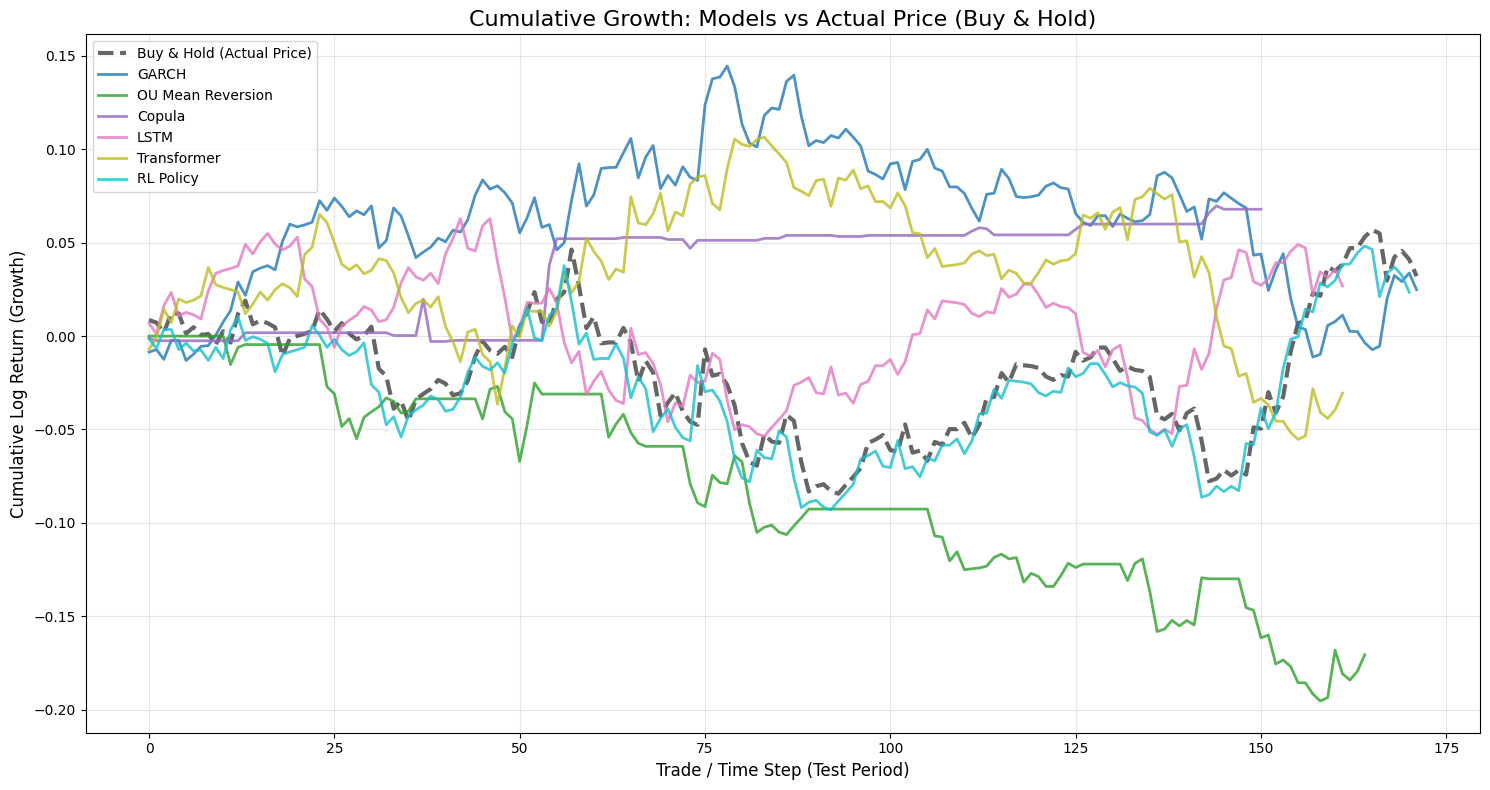

In [39]:
# ============================================================================
# VISUALIZATION: MODELS VS ACTUAL PRICE (BUY & HOLD)
# ============================================================================

def plot_model_comparison_with_price(all_results):
    """
    Plots the Equity Curve of each model against the 'Buy & Hold' (Actual Price) benchmark.
    """
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Check if we have any results
    if not all_results:
        print("No results to plot.")
        return

    # 1. Get Buy & Hold (Benchmark) from the first model's data
    # We use the longest available test set to ensure we cover the period
    first_key = list(all_results.keys())[0]
    # Extract actual returns from the first model's results
    baseline_returns = all_results[first_key]['y_true'].to_numpy()
    buy_and_hold_equity = np.cumsum(baseline_returns)
    
    # Plot Benchmark (Actual Price Movement)
    ax.plot(buy_and_hold_equity, label='Buy & Hold (Actual Price)', color='black', linewidth=3, linestyle='--', alpha=0.6)

    # 2. Plot Each Model
    # Generate distinct colors
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))
    
    for i, (model_name, trade_results) in enumerate(all_results.items()):
        equity = trade_results['equity_curve'].to_numpy()
        
        # Ensure we don't plot out of bounds if lengths differ slightly
        min_len = min(len(equity), len(buy_and_hold_equity))
        
        ax.plot(equity[:min_len], label=model_name, linewidth=2, color=colors[i], alpha=0.8)

    ax.set_title("Cumulative Growth: Models vs Actual Price (Buy & Hold)", fontsize=16)
    ax.set_ylabel("Cumulative Log Return (Growth)", fontsize=12)
    ax.set_xlabel("Trade / Time Step (Test Period)", fontsize=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("\n Generating Comparison Plot: Models vs Actual Price...\n")
plot_model_comparison_with_price(ALL_RESULTS)